SAM1 code based on https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
and https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import torch

print("CHECKING DEVICES")
if torch.backends.mps.is_available():
   # device = torch.device("mps")
   device = torch.device("mps")
   # SAM still does not fix the problems related MPS till 2026.4.14
   print("MPS is ready")

elif torch.cuda.is_available():
   device = torch.device("cuda")
   print("CUDA is ready for use")

else:
   device = torch.device("cpu")
   print("CPU is ready for use")

print(f"Final device selected: {device}\n")

CHECKING DEVICES
CUDA is ready for use
Final device selected: cuda



In [2]:
# import other libraries that is neeeded
import cv2 as cv
import numpy as np
import scipy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

import warnings
warnings.filterwarnings("ignore")

In [3]:
# read and load the images
# change the path addresses if using the Colab or other devices
test_path = 'C:/Users/leolj/Desktop/9517-proj/EWS-Dataset/test'
train_path = 'C:/Users/leolj/Desktop/9517-proj/EWS-Dataset/train' 
val_path = 'C:/Users/leolj/Desktop/9517-proj/EWS-Dataset/validation'

def load_images(path):
    all_files = os.listdir(path)
    png_files = sorted([f for f in all_files if f.lower().endswith('.png')])
    # mask file are files end with "_mask.png"
    # filter out the original images
    image_files = [f for f in png_files if not f.lower().endswith('_mask.png')]

    images = []
    masks = []
    # filenames = []
    
    for fname in image_files:
        img_path = os.path.join(path, fname)
        
        mask_name = fname.replace('.png', '_mask.png')
        mask_path = os.path.join(path, mask_name)

        img = cv.imread(img_path, cv.IMREAD_COLOR)
        mask = cv.imread(mask_path, cv.IMREAD_GRAYSCALE)

        if img is not None and mask is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

            images.append(img)
            masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)

    return images, masks


# Load all sets
test_images, test_masks  = load_images(test_path)
train_images, train_masks = load_images(train_path)
val_images, val_masks = load_images(val_path)

print("Test images shape: ", test_images.shape, val_masks.shape)
print("Train images shape:", train_images.shape, train_masks.shape)
print("Validation images shape:  ", val_images.shape, test_masks.shape)

Test images shape:  (24, 350, 350, 3) (24, 350, 350)
Train images shape: (142, 350, 350, 3) (142, 350, 350)
Validation images shape:   (24, 350, 350, 3) (24, 350, 350)


In [4]:
def compute_metrics(pred_mask, gt_mask):
    pred = (pred_mask > 0).flatten()
    gt   = (gt_mask > 0).flatten()
    
    accuracy  = accuracy_score(gt, pred)
    precision = precision_score(gt, pred)
    recall = recall_score(gt, pred)
    f1 = f1_score(gt, pred)

    # Compute Intersection-over-Union between two binary mask
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    iou = intersection / union if union > 0 else 0.0
    
    return accuracy, precision, recall, f1, iou

In [5]:
# SAM 1
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [6]:
def predict_sam_mask_with_model(image, model):
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)
    
    # Create a generator locally so that it can automatically match the passed-in model instance
    temp_generator = SamAutomaticMaskGenerator(
        model=model,
        points_per_side = 32,  
        # too densely spaced will divide large tracts of farmland into countless small squares
        # time saving
        pred_iou_thresh=0.7,
        stability_score_thresh=0.92,
        crop_n_layers=0,# Farmland is a global feature, does not require cropping before segmentation.
        crop_n_points_downscale_factor=2,
        min_mask_region_area=100,
    )
    
    try:
        masks = temp_generator.generate(image)
    except Exception:
        return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

    if not masks:
        return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

    combined = np.zeros((image.shape[0], image.shape[1]), dtype=bool)
    for m in masks:
        combined = np.logical_or(combined, m['segmentation'])

    return combined.astype(np.uint8) * 255

In [7]:
# SAM 1
# load the pre-trained model vit_b

model_type = "vit_b" # base
sam_checkpoint = "C:/Users/leolj/Desktop/9517-proj/sam_vit_b_01ec64.pth"

#  MPS does not support float64, force to use float32
if str(device) == "mps":
    device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Model predicts the masks automaticly
mask_generator = SamAutomaticMaskGenerator(
        model = sam,
        points_per_side= 32,  
        # too densely spaced will divide large tracts of farmland into countless small squares
        # time saving
        pred_iou_thresh=0.7,
        stability_score_thresh=0.92,
        crop_n_layers=0,# Farmland is a global feature, does not require cropping before segmentation.
        crop_n_points_downscale_factor=2,
        min_mask_region_area=100,
    )

# run SAM automatic mask generation and return a binary mask
def predict_sam_mask(image):
    sam.eval() 
    # move to CPU
    if torch.is_tensor(image):
        if image.dtype != torch.uint8:
            image = image.to(torch.uint8)
        image = image.cpu().numpy()
        if image.ndim == 4: image = image[0]
        if image.shape[0] == 3:
            image = image.transpose(1, 2, 0)
    else:
        if image.dtype != np.uint8:
            image = image.astype(np.uint8)

    
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            if image.dtype != np.uint8:
                image = image.astype(np.uint8)    
    
            try:
                masks = mask_generator.generate(image)
            except (IndexError, RuntimeError):
                return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        
        if not masks or len(masks) == 0:
            return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

    # conbine all instance masks
    h, w = image.shape[:2]
    combined = np.zeros((h, w), dtype=np.uint8)
    
    for m in masks:
        combined = np.logical_or(combined, m['segmentation'])

    return combined * 255

In [8]:
def evaluation(images, gt_masks, set_name="Validation", predict_fn=None):
    if predict_fn is None:
        predict_fn = predict_sam_mask
    pred_masks = []
    sam.eval()
    for i, img in enumerate(images):
        pred = predict_fn(img)
        # move result to CPU
        if torch.is_tensor(pred):
            pred_masks.append(pred.detach().cpu().numpy())
        else:
            pred_masks.append(pred) 
        
    pred_masks = np.array(pred_masks)

    acc_list, prec_list, rec_list, f1_list, iou_list = [], [], [], [], []
    for pred, gt in zip(pred_masks, gt_masks):
      if pred.shape != gt.shape:
          gt = cv.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv.INTER_NEAREST)
      a, p, r, f, i = compute_metrics(pred, gt)

      acc_list.append(a)
      prec_list.append(p)
      rec_list.append(r)
      f1_list.append(f)
      iou_list.append(i)

    print(f"\nSAM (vit_b) Zero-Shot on {set_name}")
    print(f"Accuracy  : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall    : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    print(f"F1-score  : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"IoU       : {np.mean(iou_list):.4f} ± {np.std(iou_list):.4f}")
    return pred_masks

In [9]:
# zero-shot evaluation on val
val_pred_masks = evaluation(
    val_images, 
    val_masks, 
    "Validation (Zero-Shot)", 
    predict_fn=lambda img: predict_sam_mask_with_model(img, sam))

# free cashe
torch.cuda.empty_cache()


SAM (vit_b) Zero-Shot on Validation (Zero-Shot)
Accuracy  : 0.3902 ± 0.2260
Precision : 0.5912 ± 0.3085
Recall    : 0.3677 ± 0.2538
F1-score  : 0.4038 ± 0.2355
IoU       : 0.2909 ± 0.2603


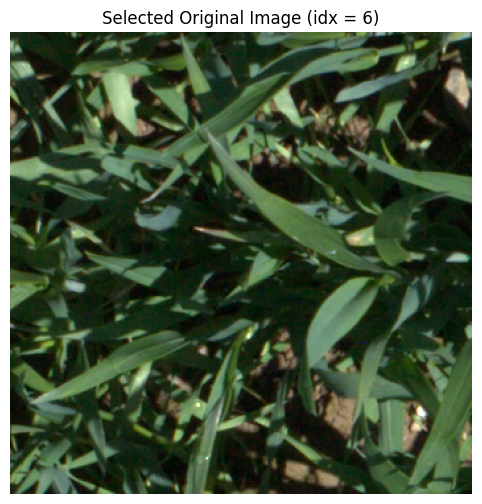

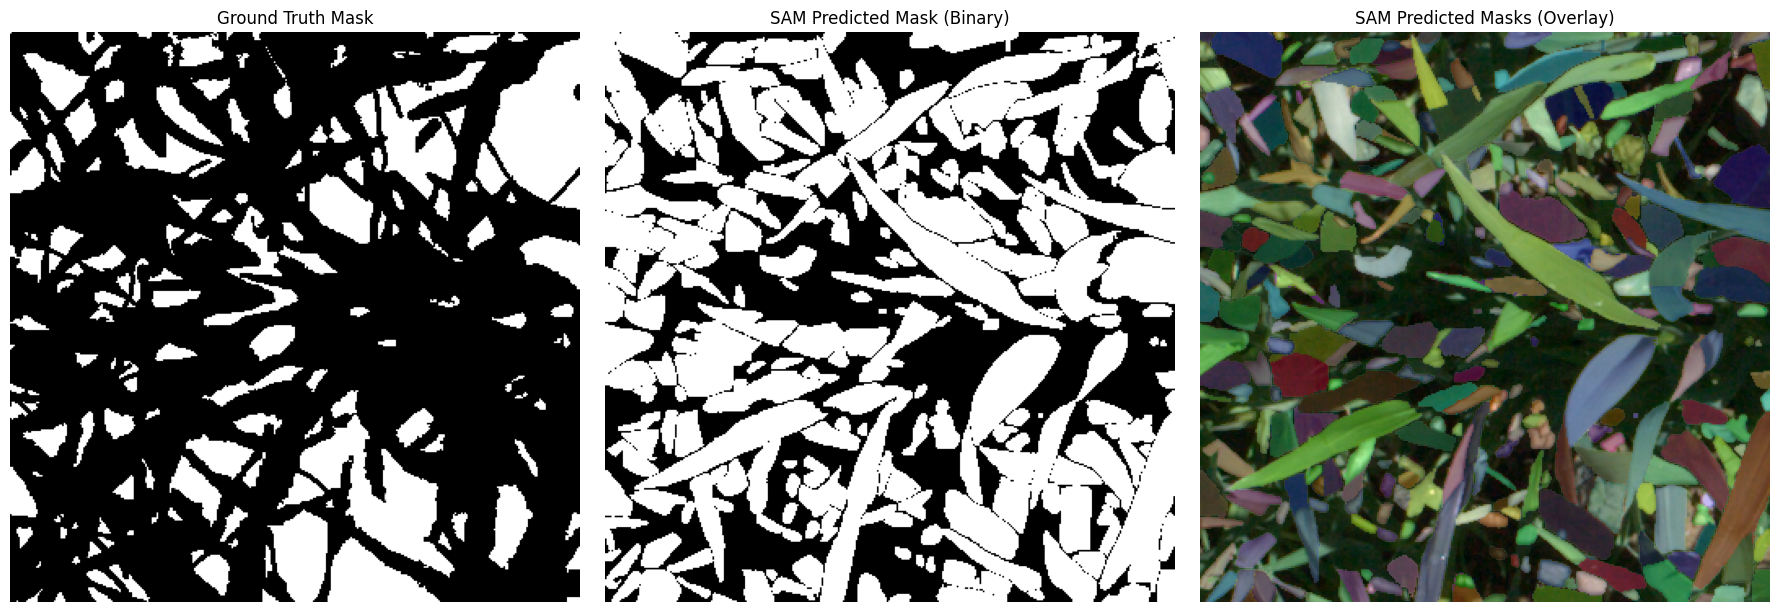

In [10]:
import gc

# compare the ground truth mask and predicted mask visually.
# pick up an image randmly to compare
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

with torch.no_grad():
    idx = random.randint(0, len(val_images)-1)
    img = val_images[idx]
    gt  = val_masks[idx]

    img_uint8 = img.astype(np.uint8) if img.dtype != np.uint8 else img

    torch.cuda.empty_cache()
    pred = predict_sam_mask(img)

    anns = mask_generator.generate(img.astype(np.uint8) if img.dtype != np.uint8 else img)

gc.collect()

# display the chose picture
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Selected Original Image (idx = {idx})")
plt.axis('off')
plt.show()

# GT Mask vs Predicted Mask visually
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(gt, cmap='gray')
ax[0].set_title("Ground Truth Mask")
ax[0].axis('off')

ax[1].imshow(pred, cmap='gray')
ax[1].set_title("SAM Predicted Mask (Binary)")
ax[1].axis('off')

# overlay
ax[2].imshow(img)
show_anns(anns)
ax[2].set_title("SAM Predicted Masks (Overlay)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

del anns, pred
torch.cuda.empty_cache()

In [11]:
# LoRA for SAM1
# partial LoRA
import torch.nn as nn

class LoRASAM(nn.Module):
    def __init__(self, module, in_dim, out_dim, rank=4):
        super().__init__()
        self.module = module

        self.A = nn.Parameter(torch.randn(in_dim, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, out_dim))

        self.scale = 1.0 / rank

        for p in self.module.parameters():
            p.requires_grad = False

    def forward(self, x):
        lora_out = (x @ self.A @ self.B) * self.scale
        return self.module(x) + lora_out

# Query Key Value
# Inject into the QKV
def inject_lora_sam(sam, device, rank=4, num_trainable_blocks=8):
    sam.to(device)

    total_blocks = len(sam.image_encoder.blocks)
    start_block = total_blocks - num_trainable_blocks
    
    for i, block in enumerate(sam.image_encoder.blocks):

        if i < start_block:
            continue
        
        qkv = block.attn.qkv

        # avoid repeatly inject
        if isinstance(qkv, LoRASAM):
            continue

        # use dummy forward to get the dimension
        in_dim = block.attn.proj.weight.shape[1]

        dummy = torch.randn(1, 1, in_dim, device=device)

        with torch.no_grad():
            out = qkv(dummy)

        out_dim = out.shape[-1]

        # replace
        block.attn.qkv = LoRASAM(qkv, in_dim, out_dim, rank)

    return sam

# freeze and train Setup
def setup_training(sam):
    # freeze all
    for p in sam.parameters():
        p.requires_grad = False

    # unfreeze LoRA only
    for block in sam.image_encoder.blocks:
        if isinstance(block.attn.qkv, LoRASAM):
            for p in block.attn.qkv.parameters():
                p.requires_grad = True
    
    # unfreeze mask decoder # GPU memory is not enough
    # for p in sam.mask_decoder.parameters():
    #    p.requires_grad = True
    
    sam.train()
    return sam


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = inject_lora_sam(sam, device, rank=4)

initial_weights = {k: v.cpu().clone() for k, v in sam.state_dict().items()}

sam.to(device)

if str(device) == "mps":
    sam = sam.float()

sam = setup_training(sam)

In [12]:
def get_lora_state_dict(model):
    return {k: v for k, v in model.state_dict().items() if "lora" in k}

In [13]:
# Gradient Checkpoint Wrapper - for opt GPU memory
from torch.utils.checkpoint import checkpoint

class CheckpointWrapper(nn.Module):
    def __init__(self, module):
        super().__init__()
        self.module = module
    def forward(self, x, *args, **kwargs):
        return checkpoint(self.module, x, *args, use_reentrant=False, **kwargs)

def apply_checkpointing(model):
    """Enable GPU memory re-computation only for blocks containing LoRA parameters"""
    for i in range(len(model.image_encoder.blocks)):
        block = model.image_encoder.blocks[i]
        if any(p.requires_grad for p in block.parameters()):
            model.image_encoder.blocks[i] = CheckpointWrapper(block)

In [14]:
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 3 # for saving time
import torch.nn.functional as F

class SimpleDataset:
    def __init__(self, images, masks):
        self.images = [torch.from_numpy(i).permute(2,0,1).float()/255.0 for i in images]
        self.masks  = [torch.from_numpy(m).unsqueeze(0).float()/255.0 for m in masks]

    def __len__(self): return len(self.images)
    def __getitem__(self, i): 
        # Convert to a Tensor only when necessary to conserve system memory
        img_item = self.images[i]
        mask_item = self.masks[i]

        # --- Added robustness check ---
        # Process the image
        if isinstance(img_item, np.ndarray):
            img = torch.from_numpy(img_item).permute(2, 0, 1).float() / 255.0
        else:
            # If it is already a Tensor, ensure the dimensions are correct and normalize
            img = img_item.float()
            if img.max() > 1.0: img /= 255.0
            if img.ndim == 3 and img.shape[-1] == 3: # If HWC, convert to CHW
                img = img.permute(2, 0, 1)

        # Process the mask
        if isinstance(mask_item, np.ndarray):
            mask = torch.from_numpy(mask_item).unsqueeze(0).float() / 255.0
        else:
            mask = mask_item.float()
            if mask.max() > 1.0: mask /= 255.0
            if mask.ndim == 2: mask = mask.unsqueeze(0)

        return img, mask

def forward_sam(img):
    # preprocess and transform into sam need
    img_input  = sam.preprocess(img * 255.0)

    with autocast():
        emb = sam.image_encoder(img_input)

        with torch.no_grad():
            sparse, dense = sam.prompt_encoder(points=None, boxes=None, masks=None)

        low_res, _ = sam.mask_decoder(
            image_embeddings=emb,
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse,
            dense_prompt_embeddings=dense,
            multimask_output=False,
        )

        #masks = sam.postprocess_masks(
        #    low_res,
        #    input_size=img_input.shape[-2:],
        #    original_size=img_input.shape[-2:]
        #)

        # return the 256x256 `low_res` directly while training
        # `loss_fn` handles the resizing, saving GPU memory
        return low_res

# avoid set-up repeatly
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(logits, gt):
    if logits.dim() == 3:
        logits = logits.unsqueeze(1)
    if gt.dim() == 3:
        gt = gt.unsqueeze(1)
    if gt.shape[-2:] != logits.shape[-2:]:
        gt = F.interpolate(gt, size=logits.shape[-2:], mode='nearest')

    bce = nn.BCEWithLogitsLoss()(logits, gt)

    pred = torch.sigmoid(logits)
    inter = (pred * gt).sum()
    sets_sum = pred.sum() + gt.sum()
    dice = 1 - (2 * inter + 1e-5) / (sets_sum + 1e-5)
    
    return bce + dice

def train(images, masks):
    loader = torch.utils.data.DataLoader(
        SimpleDataset(images, masks), batch_size=1, shuffle=True
    )

    # Automatically retrieve all parameters with `requires_grad=True` (including unfrozen LoRA and mask_decoder)
    trainable_params = [p for p in sam.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable_params, lr=1e-4)
    scaler = GradScaler()

    sam.train()
    apply_checkpointing(sam)
    
    for e in range(EPOCHS):
        loss_sum = 0
        for batch_idx, (img, gt) in enumerate(loader):
            img, gt = img.to(device), gt.to(device)

            opt.zero_grad(set_to_none=True)
            
            with autocast():
                logits = forward_sam(img)
                loss = loss_fn(logits, gt)

            # Backpropagation
            scaler.scale(loss).backward()

            # Gradient Clipping
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)

            # update param
            scaler.step(opt)
            scaler.update()
            
            loss_sum += loss.item()

            del img, gt, logits, loss
            
        print(f"Epoch {e+1}: {loss_sum/len(loader):.4f}")
        torch.cuda.empty_cache()

# 1. Direct Training
print("Direct Training")
sam.load_state_dict(initial_weights)
sam.to(device)
apply_checkpointing(sam)

train(train_images, train_masks)

torch.save(get_lora_state_dict(sam), "lora_direct.pth")
torch.cuda.empty_cache()

# 2. K-Fold Training
print("\nk-Fold Training, k = 5")

n = len(train_images)
idx = np.random.permutation(n)
fold_size = n // 5

for f in range(5):
    print(f"Fold {f+1}")

    # Reset model weights to prevent data leakage between folds
    sam.load_state_dict(initial_weights, strict=False)
    sam.to(device)
    
    apply_checkpointing(sam) 
    
    val_idx = idx[f*fold_size : (f+1)*fold_size]
    tr_idx = np.setdiff1d(idx, val_idx)

    train(train_images[tr_idx], train_masks[tr_idx])

    gc.collect() 
    torch.cuda.empty_cache()

torch.save(get_lora_state_dict(sam), "lora_kfold.pth")
torch.cuda.empty_cache()

def predict(image):
    sam.eval()
    img = torch.from_numpy(image).permute(2,0,1).float().unsqueeze(0)/255.0
    img = img.to(device)

    with torch.no_grad():
        with autocast():
            # During the inference phase, you can use `postprocess` to obtain the full-size mask.
            img_input = sam.preprocess(img * 255.0) 
            emb = sam.image_encoder(img_input)
            sparse, dense = sam.prompt_encoder(points=None, boxes=None, masks=None)
            
            low_res, _ = sam.mask_decoder(
                image_embeddings=emb,
                image_pe=sam.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse,
                dense_prompt_embeddings=dense,
                multimask_output=False,
            )
            # resize to original
            upscaled_masks = sam.postprocess_masks(low_res, img_input.shape[-2:], img_input.shape[-2:])
            pred = torch.sigmoid(upscaled_masks[:, 0])

    return (pred[0].cpu().numpy() > 0.5).astype(np.uint8) * 255

Direct Training
Epoch 1: 2.7291
Epoch 2: 0.6340
Epoch 3: 0.6237

k-Fold Training, k = 5
Fold 1
Epoch 1: 0.6040
Epoch 2: 0.5954
Epoch 3: 0.5887
Fold 2
Epoch 1: 0.6189
Epoch 2: 0.6104
Epoch 3: 0.5960
Fold 3
Epoch 1: 0.5725
Epoch 2: 0.5604
Epoch 3: 0.5492
Fold 4
Epoch 1: 0.5481
Epoch 2: 0.5343
Epoch 3: 0.5264
Fold 5
Epoch 1: 0.5377
Epoch 2: 0.5315
Epoch 3: 0.5265


In [15]:
# 3. Compare the 2 training methods and base on Val
# before lora(base SAM)
sam_base = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam_base.to(device)
sam_base.eval()

with torch.no_grad():
    val_base = evaluation(
        val_images, 
        val_masks, 
        "Validation (Base SAM)", 
        predict_fn=lambda img: predict_sam_mask_with_model(img, sam_base)
    )

del sam_base
torch.cuda.empty_cache()


SAM (vit_b) Zero-Shot on Validation (Base SAM)
Accuracy  : 0.3902 ± 0.2260
Precision : 0.5912 ± 0.3085
Recall    : 0.3677 ± 0.2538
F1-score  : 0.4038 ± 0.2355
IoU       : 0.2909 ± 0.2603


In [16]:
# LoRA Direct
sam_direct = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
# must load the structure first, then apply the weights.
sam_direct = inject_lora_sam(sam_direct, device, rank=4)

lora_weights_direct = torch.load("lora_direct.pth", map_location=device)
missing, unexpected = sam_direct.load_state_dict(lora_weights_direct, strict=False)

sam_direct.to(device)
sam_direct.eval()

with torch.no_grad():
    val_direct = evaluation(
        val_images, 
        val_masks, 
        "Validation (LoRA Direct)", 
        predict_fn=lambda img: predict_sam_mask_with_model(img, sam_direct)
    )

del sam_direct
gc.collect()
torch.cuda.empty_cache()


SAM (vit_b) Zero-Shot on Validation (LoRA Direct)
Accuracy  : 0.3902 ± 0.2260
Precision : 0.5912 ± 0.3085
Recall    : 0.3677 ± 0.2538
F1-score  : 0.4038 ± 0.2355
IoU       : 0.2909 ± 0.2603


In [17]:
# LoRA K-Fold
sam_kfold = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")

sam_kfold = inject_lora_sam(sam_kfold, device, rank=4)

lora_weights_kfold = torch.load("lora_kfold.pth", map_location=device)
missing, unexpected = sam_kfold.load_state_dict(lora_weights_kfold, strict=False)

sam_kfold.to(device)
sam_kfold.eval()

with torch.no_grad():
    val_kfold = evaluation(
        val_images, 
        val_masks, 
        "Validation (LoRA KFold)", 
        predict_fn=lambda img: predict_sam_mask_with_model(img, sam_kfold)
    )

del sam_kfold
gc.collect()
torch.cuda.empty_cache()


SAM (vit_b) Zero-Shot on Validation (LoRA KFold)
Accuracy  : 0.3902 ± 0.2260
Precision : 0.5912 ± 0.3085
Recall    : 0.3677 ± 0.2538
F1-score  : 0.4038 ± 0.2355
IoU       : 0.2909 ± 0.2603


In [18]:
# compute IoU
iou_b = np.mean([compute_metrics(p,g)[4] for p,g in zip(val_base, val_masks)])
iou_d = np.mean([compute_metrics(p,g)[4] for p,g in zip(val_direct, val_masks)])
iou_k = np.mean([compute_metrics(p,g)[4] for p,g in zip(val_kfold, val_masks)])

print(f"\nBase IoU: {iou_b:.4f}")
print(f"Direct IoU: {iou_d:.4f}")
print(f"K-Fold IoU: {iou_k:.4f}")


Base IoU: 0.2909
Direct IoU: 0.2909
K-Fold IoU: 0.2909


In [19]:
# select best model
ious = {"Base": iou_b, "Direct": iou_d, "K-Fold": iou_k}
Train_Model = max(ious, key=ious.get)

print(f"Use {Train_Model}")


Best_Model = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")

if Train_Model != "Base":
    Best_Model = inject_lora_sam(Best_Model, device, rank=4)
    weight_path = "lora_direct.pth" if Train_Model == "Direct" else "lora_kfold.pth"
    Best_Model.image_encoder.load_state_dict(torch.load(weight_path))

Best_Model.to(device)
Best_Model.eval()

Use Base


Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [20]:
# Test set, for final report
test_pred_masks = evaluation(
    test_images, 
    test_masks, 
    f"TEST ({Train_Model})", 
    predict_fn=lambda img: predict_sam_mask_with_model(img, Best_Model)
)


SAM (vit_b) Zero-Shot on TEST (Base)
Accuracy  : 0.3852 ± 0.1821
Precision : 0.5545 ± 0.2784
Recall    : 0.3474 ± 0.2141
F1-score  : 0.3944 ± 0.1976
IoU       : 0.2717 ± 0.2150
